### Column Consistency Check Across CSV Files

Before merging multiple CSV files into a single dataset, it is important to verify that all files share the same column structure. Differences in column names or ordering can lead to incorrect merging and introduce missing values.

The following code performs a column validation step:

1. All CSV files in the specified directory are located using the `glob` library.
2. The column names from the first CSV file are used as the reference schema.
3. For each remaining file, only the header (column names) is read using `pandas.read_csv()` with `nrows=0`, which avoids loading the full dataset into memory.
4. The column structure of each file is compared with the reference columns.
5. A message is printed indicating whether the columns match or if a mismatch is detected.

This approach ensures structural consistency across all datasets before concatenating them into a single dataframe.

In [1]:
import pandas as pd
import glob

files = glob.glob(r"C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\*.csv") # Locates all the csv files in the specified directory

base_columns = pd.read_csv(files[0], nrows=0).columns

for file in files[1:]:
    current_columns = pd.read_csv(file, nrows=0).columns
    
    if not base_columns.equals(current_columns):
        print(f"Column mismatch found in {file}")
    else:
        print(f"{file} columns match")

C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Morning.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Monday-WorkingHours.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Tuesday-WorkingHours.pcap_ISCX.csv columns match
C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Wednesday-workingHours.pcap_ISCX.csv columns match


### Detecting Negative Values in Numeric Features

This code iterates through all CSV files in the dataset directory and checks for the presence of negative values in numeric columns.

First, each CSV file is loaded into a temporary pandas DataFrame. To ensure accurate datatype inference, the `low_memory=False` parameter is used when reading the file.

Next, only numeric columns are selected using the `select_dtypes()` function. This step is important because negative values are meaningful only for numeric data and not for categorical or textual features.

The code then evaluates whether any values in these numeric columns are less than zero. A boolean comparison (`numeric_df < 0`) is performed, and the resulting True values are summed column-wise to count how many negative values appear in each column.

Columns that contain at least one negative value are filtered and stored. If such columns exist in the file, the script prints the file name along with the column names and the number of negative entries detected.

This process helps identify potential data quality issues, anomalies, or unexpected values within the dataset before further preprocessing or model training.

In [2]:
for file in files:  
    # Iterate through each CSV file path stored in the list "files"

    df_temp = pd.read_csv(file, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()  # Removes leading and trailing spaces from column names
    # Read the current CSV file into a temporary pandas DataFrame
    # low_memory=False ensures pandas reads the file in one pass for correct datatype inference

    numeric_df = df_temp.select_dtypes(include='number')  
    # Select only the columns that contain numeric values (integers or floats)
    # This avoids checking negative values in non-numeric columns like text or IP addresses

    negative_counts = (numeric_df < 0).sum()  
    # Create a boolean dataframe where values < 0 are True
    # Then sum the True values column-wise to count how many negative values each column contains

    negative_columns = negative_counts[negative_counts > 0]  
    # Filter the results to keep only columns where the count of negative values is greater than zero

    if not negative_columns.empty:  
        # Check whether any columns with negative values were found

        print(f"\nNegative values in file: {file}")  
        # Print the name/path of the file where negative values were detected

        print(negative_columns)  
        # Display the column names along with the number of negative values detected


Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Flow Duration                  2
Flow Bytes/s                   2
Flow Packets/s                 2
Flow IAT Mean                  2
Flow IAT Max                   2
Flow IAT Min                 108
Fwd IAT Min                    6
Init_Win_bytes_forward     32925
Init_Win_bytes_backward    88299
dtype: int64

Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Flow Duration                 36
Flow Bytes/s                  36
Flow Packets/s                36
Flow IAT Mean                 36
Flow IAT Max                  36
Flow IAT Min                 176
Init_Win_bytes_forward     60210
Init_Win_bytes_backward    76942
dtype: int64

Negative values in file: C:\Folder_to_migrate\Study\MS-AAI\Modules\AAI-501\Project\Dataset_finalised\Frida

### Merging Multiple CSV Files into a Single DataFrame and Cleaning Dataset Columns

This code combines multiple CSV files into a single DataFrame and performs essential column cleaning to ensure consistency and remove redundancy.

First, all CSV files are read and concatenated using `pd.concat()`. The `ignore_index=True` parameter ensures that the row indices are reset, creating a continuous index across the merged dataset.

Next, column names are cleaned by removing any leading or trailing whitespace using `str.strip()`. This prevents issues caused by inconsistent formatting in column headers.

Since the dataset may contain duplicate columns, Pandas automatically appends suffixes such as `.1`, `.2`, etc., to make column names unique during loading. These suffixes are removed using a regular expression so that logically identical columns can be identified.

Finally, duplicate columns are removed by retaining only the first occurrence of each column name using `df.loc[:, ~df.columns.duplicated()]`. This step ensures that redundant features are eliminated, resulting in a cleaner and more reliable dataset.

The `df.info()` function is then used to display a concise summary of the DataFrame, including column names, data types, and non-null counts, while `df.head()` provides a preview of the first few rows for inspection.

In [3]:
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True) # Reads each csv file and concatenates them into a single dataframe, ignoring the original index
df.columns = df.columns.str.strip()  # Removes leading and trailing spaces from column names
df.columns = df.columns.str.replace(r'\.\d+$', '', regex=True) # Removes suffixes like '.1', '.2', etc. from column names (added by pandas for duplicate columns),
# so that logically identical columns can be recognized and handled properly
df = df.loc[:, ~df.columns.duplicated()] # Removes duplicate columns by keeping only the first occurence of each column name

In [4]:
df.info() # Displays a concise summary of the DataFrame
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 78 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


**Pre-check for clean up** <br>
Grouping the dataset by the Label column to calculate the number of missing values for each feature within each class. Then filtering out columns with no missing values to focus only on relevant features. This helps understand how missing data is distributed across different categories (e.g., benign vs attack).

In [5]:
missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())

# Filter only columns with missing values
missing_by_label = missing_by_label.loc[:, missing_by_label.sum() > 0]

print(missing_by_label)

missing = df.isna().sum()

C:\Users\kalyan_developer\AppData\Local\Temp\ipykernel_14632\4248142842.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())


                            Flow Bytes/s
Label                                   
BENIGN                               409
Bot                                    0
DDoS                                   0
DoS GoldenEye                          0
DoS Hulk                             949
DoS Slowhttptest                       0
DoS slowloris                          0
FTP-Patator                            0
Heartbleed                             0
Infiltration                           0
PortScan                               0
SSH-Patator                            0
Web Attack � Brute Force               0
Web Attack � Sql Injection             0
Web Attack � XSS                       0


### Handling Negative Values in TCP Window Size Features

During exploratory data analysis, the features **`Init_Win_bytes_forward`** and **`Init_Win_bytes_backward`** were found to contain a large number of negative values. These variables represent the initial TCP window size advertised by the client and the server during the establishment of a TCP connection. Since TCP window sizes represent the number of bytes that can be received before an acknowledgment is required, these values cannot be negative in practice.

In the CICIDS dataset, negative values (commonly `-1`) typically indicate that the TCP window size information was **missing, unavailable, or not applicable** for a particular flow. This situation can occur when only one direction of the flow was captured, when the flow was not based on the TCP protocol, or when the feature extraction process could not determine the window size.

Because these two columns contained **a very large number of negative values**, removing all rows with such entries would have resulted in the loss of a substantial portion of the dataset and could potentially bias the analysis or reduce the effectiveness of the machine learning model. Therefore, instead of dropping those rows, negative values were replaced with **0** using the `clip(lower=0)` function. This transformation ensures that invalid negative values are corrected while preserving the dataset size and maintaining logical consistency in the features.


In [6]:
df['Init_Win_bytes_forward'] = df['Init_Win_bytes_forward'].clip(lower=0)
df['Init_Win_bytes_backward'] = df['Init_Win_bytes_backward'].clip(lower=0)

### Removing Rows with Negative Values and Analyzing Label Distribution

This code performs data cleaning by removing rows that contain negative values in any numeric column and then analyzes the distribution of labels in the dataset.

First, the total number of rows in the dataset is stored in the variable `before`. A filtering condition is then applied to retain only those rows where all numeric features are greater than or equal to zero. This is achieved by selecting numeric columns, checking for non-negative values, and ensuring that the condition holds true across each row.

After filtering, the updated number of rows is stored in the variable `after`. The difference between `before` and `after` gives the total number of rows removed due to invalid negative values, which is printed for reference.

Finally, the distribution of the target variable (`Label`) is examined using `value_counts()`. This provides the frequency of each class in the cleaned dataset, helping to understand class balance and the impact of data cleaning on different categories.

In [7]:
before = len(df)
df = df[(df.select_dtypes(include='number') >= 0).all(axis=1)]
after = len(df)
print(f"Rows removed: {before - after}")
df['Label'].value_counts()

Rows removed: 4283


Label
BENIGN                        2269957
DoS Hulk                       229965
PortScan                       158930
DDoS                           128008
DoS GoldenEye                   10288
FTP-Patator                      7934
SSH-Patator                      5895
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       35
Web Attack � Sql Injection         21
Heartbleed                          7
Name: count, dtype: int64

### Detection and Removal of Infinite Values

The dataset was examined for the presence of infinite values, which can arise due to division-based feature calculations such as rates (e.g., bytes per second or packets per second). These values typically occur when the denominator in a calculation is zero, leading to undefined or extremely large results.

Since infinite values can negatively impact machine learning algorithms and lead to training failures, a preprocessing step is performed to identify and remove them.

First, only numerical columns were selected, as infinite values are applicable only to numeric data types. A boolean mask was then created to detect rows containing infinite values across any numerical feature. Additionally, the number of infinite values present in each column was calculated to identify problematic features.

Finally, all rows containing infinite values were removed from the dataset, ensuring that the data used for model training consists only of valid and finite numerical values. This step improves the stability and reliability of subsequent modeling processes.

In [8]:
import numpy as np
numeric_df = df.select_dtypes(include=[np.number])
inf_mask = np.isinf(numeric_df).any(axis=1) # Creating a boolean mask where True indicates row contains infinite values
inf_count = np.isinf(numeric_df).sum()

# Show only columns where inf exists
inf_count = inf_count[inf_count > 0]

print("\nCount of infinite values per column:")
print(inf_count)

# Remove rows with infinite values
df = df[~inf_mask]


Count of infinite values per column:
Flow Bytes/s      1509
Flow Packets/s    1509
dtype: int64



### Missing and Infinite Value Analysis post data cleaning

The dataset was analyzed to detect missing and infinite values that could affect model performance.

Missing values were computed by grouping the data based on the target variable (`Label`) to understand their distribution across traffic types. Only columns containing missing values were displayed for focused analysis.

For infinite values, only numerical features were considered. The count of infinite values per column was calculated and displayed for columns where such values were present.

If no missing or infinite values were found, appropriate messages were printed. This step ensures data quality before proceeding with preprocessing and model training.

In [9]:
missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())

# Filter only columns with missing values
missing_by_label = missing_by_label.loc[:, missing_by_label.sum() > 0]

if missing_by_label.empty:
    print("No missing values found in any column after filtering.")
else:
    print(missing_by_label)

# Filter rows containing infinite values

numeric_df = df.select_dtypes(include=[np.number])
inf_count = np.isinf(numeric_df).sum()

# Show only columns where inf exists
inf_count = inf_count[inf_count > 0]

if inf_count.empty:
    print("No infinite values found in any column after filtering.")
else:
    print("\nCount of infinite values per column:")
    print(inf_count)


C:\Users\kalyan_developer\AppData\Local\Temp\ipykernel_14632\2196788420.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_label = df.groupby("Label").apply(lambda x: x.isna().sum())


No missing values found in any column after filtering.
No infinite values found in any column after filtering.


## Distribution of Network Traffic Labels

The below visualization represents the distribution of different network traffic categories in the dataset using a horizontal count plot.

### Key Observations:

- The dataset is **highly imbalanced**, with **BENIGN traffic dominating** the dataset by a very large margin.
- Among attack types, **DoS Hulk**, **PortScan**, and **DDoS** have relatively higher occurrences compared to others.
- Several attack categories such as:
  - Heartbleed  
  - SQL Injection  
  - Infiltration  
  - Web Attacks (XSS, Brute Force)  
  have **extremely low sample counts**.

### Interpretation:

- The imbalance indicates that a model trained directly on this dataset may become **biased toward predicting the majority class (BENIGN)**.
- Rare attack types may be **poorly learned or completely ignored** by the model.

### Implications for Modeling:

- This imbalance motivates the need for:
  - Reformulating the problem as **binary classification (BENIGN vs ATTACK)**

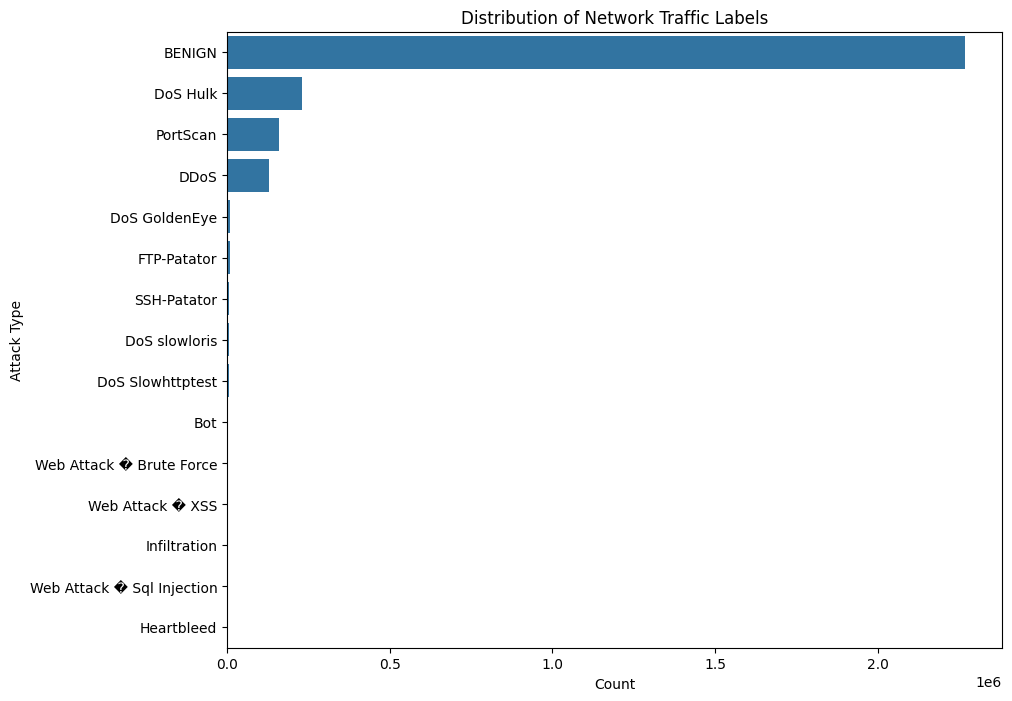

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
order = df["Label"].value_counts().index # Retrieving the unique labels sorted by their frequency

plt.figure(figsize=(10,8))
sns.countplot(data=df, y="Label", order=order)

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Count")
plt.ylabel("Attack Type")

plt.show()

## Feature Selection using Correlation Analysis

In this step, feature selection was performed to reduce redundancy and improve model efficiency.

### Approach:

1. **Correlation Matrix Computation**
   - Only numerical features were selected from the dataset.
   - A correlation matrix was computed to measure the relationship between each pair of features.

2. **Removing Duplicate Relationships**
   - Only the **upper triangle** of the correlation matrix was considered to avoid duplicate feature pairs.

3. **Identifying Highly Correlated Features**
   - A threshold of **0.95** was used.
   - Feature pairs with correlation greater than this threshold were considered highly correlated.
   - A total of **57 highly correlated pairs** were identified.

4. **Feature Reduction**
   - From each highly correlated pair, one feature was removed to eliminate redundancy.
   - This resulted in:
     - **25 features removed**
     - **52 features retained**

5. **Final Dataset Creation**
   - A reduced dataset (`df_selected`) was created using the selected features along with the target variable (`Label`).

### Results:

- **Original dataset shape:** (2,826,460, 78)
- **Reduced dataset shape:** (2,826,460, 53)

### Interpretation:

- Many features in the dataset were found to be **highly correlated or derived from each other**, indicating redundancy.
- Removing such features helps:
  - Reduce dimensionality  
  - Improve model training speed  
  - Minimize overfitting  
  - Enhance interpretability  

### Result:

Correlation-based feature selection effectively reduced the feature space while preserving the most informative attributes, preparing the dataset for efficient machine learning modeling.

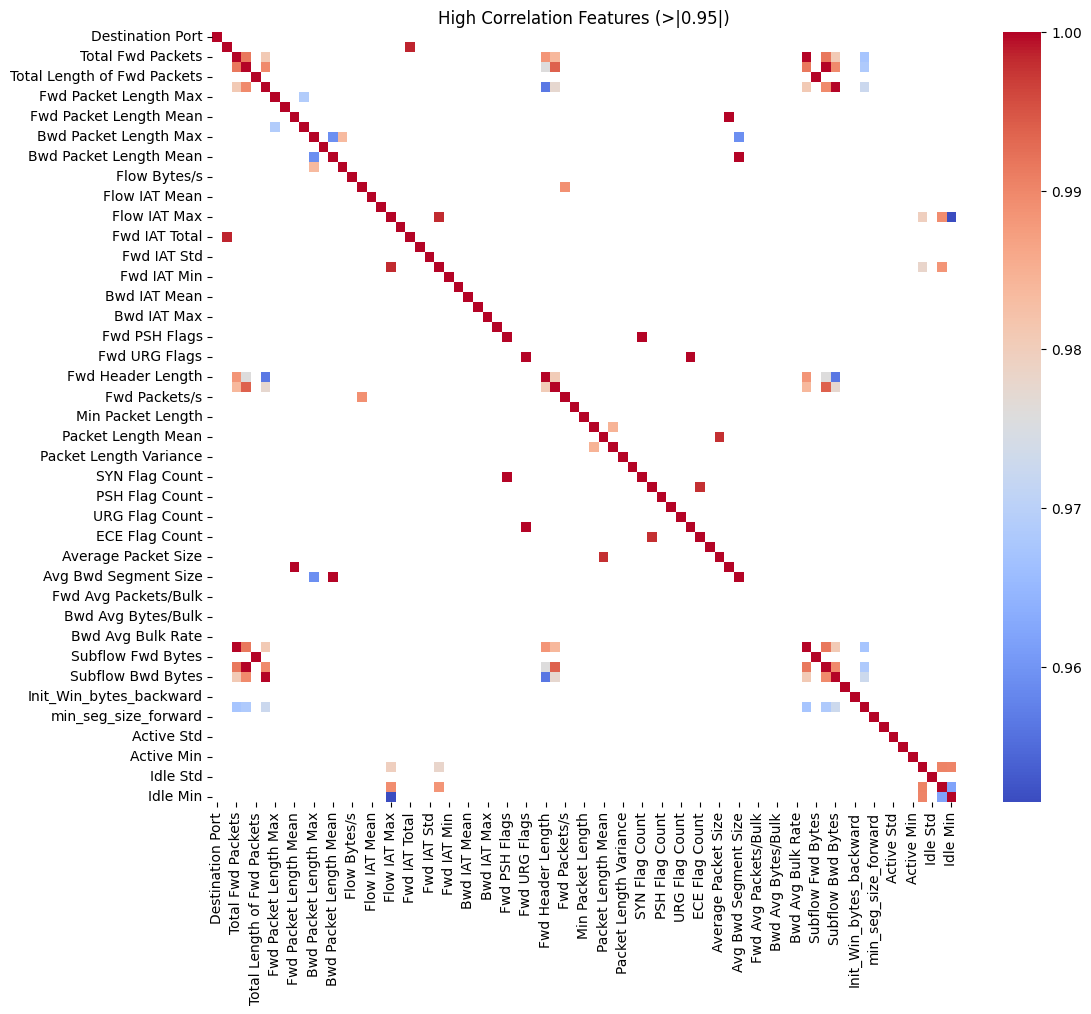

In [11]:
import numpy as np

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

# Keep only strong correlations
threshold = 0.95
corr_filtered = corr[(np.abs(corr) > threshold)]

plt.figure(figsize=(12,10))
sns.heatmap(corr_filtered, cmap='coolwarm', annot=False)
plt.title("High Correlation Features (>|0.95|)")
plt.show()

In [12]:
# Step 1: Compute correlation
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

# Step 2: Take upper triangle only (avoid duplicates)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Step 3: Find highly correlated pairs
threshold = 0.95

high_corr_pairs = [
    (col1, col2, upper.loc[col1, col2])
    for col1 in upper.columns
    for col2 in upper.columns
    if abs(upper.loc[col1, col2]) > threshold
]

# Step 4: Print results
for col1, col2, corr_value in high_corr_pairs:
    print(f"{col1}  ↔  {col2}  →  {corr_value:.2f}")

# Step 5: Find columns to DROP

to_drop = [
    col for col in upper.columns
    if any(abs(upper[col]) > threshold)
]

# Step 6: Columns to KEEP
selected_columns = [col for col in numeric_df.columns if col not in to_drop]

print(f"\nTotal highly correlated pairs (>|{threshold}|): {len(high_corr_pairs)}")
print(f"Columns to drop: {len(to_drop)}")
print(f"Columns to keep: {len(selected_columns)}")
print("\nSelected columns are given below :")
for col in selected_columns:
    print(col)

# Step 7 : Feature selection using correlation threshold
df_selected = df[selected_columns + ["Label"]]
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Selected dataset shape: {df_selected.shape}")

Flow Duration  ↔  Fwd IAT Total  →  1.00
Total Fwd Packets  ↔  Total Backward Packets  →  0.99
Total Fwd Packets  ↔  Total Length of Bwd Packets  →  0.98
Total Fwd Packets  ↔  Fwd Header Length  →  0.99
Total Fwd Packets  ↔  Bwd Header Length  →  0.98
Total Fwd Packets  ↔  Subflow Fwd Packets  →  1.00
Total Fwd Packets  ↔  Subflow Bwd Packets  →  0.99
Total Fwd Packets  ↔  Subflow Bwd Bytes  →  0.98
Total Fwd Packets  ↔  act_data_pkt_fwd  →  0.97
Total Backward Packets  ↔  Total Length of Bwd Packets  →  0.99
Total Backward Packets  ↔  Fwd Header Length  →  0.98
Total Backward Packets  ↔  Bwd Header Length  →  0.99
Total Backward Packets  ↔  Subflow Fwd Packets  →  0.99
Total Backward Packets  ↔  Subflow Bwd Packets  →  1.00
Total Backward Packets  ↔  Subflow Bwd Bytes  →  0.99
Total Backward Packets  ↔  act_data_pkt_fwd  →  0.97
Total Length of Fwd Packets  ↔  Subflow Fwd Bytes  →  1.00
Total Length of Bwd Packets  ↔  Fwd Header Length  →  0.96
Total Length of Bwd Packets  ↔  Bwd Head

### Binary Label Encoding for Intrusion Detection

The original dataset contains multiple traffic categories, including one normal class (`BENIGN`) and several attack classes (e.g., DoS, DDoS, PortScan, etc.). Since the objective of this project is to build a Network Intrusion Detection System (IDS) that distinguishes between normal and malicious traffic, the multi-class labels are transformed into a binary classification problem.

In this transformation:
- `BENIGN` traffic is encoded as **0** (normal behavior)
- All other categories are grouped and encoded as **1** (attack traffic)

To ensure robustness, the label values are cleaned using string operations (`strip` and `upper`) to handle inconsistencies such as extra spaces or variations in letter casing.

This binary encoding simplifies the modeling process, aligns with real-world IDS use cases (attack vs normal detection), and enables the application of both supervised and unsupervised machine learning algorithms effectively.

In [13]:
import numpy as np

df["Traffic_Label"] = np.where(
    df["Label"].str.strip().str.upper() == "BENIGN",
    0,
    1
)
print("0 = Benign, 1 = Attack")
print(df["Traffic_Label"].value_counts())

0 = Benign, 1 = Attack
Traffic_Label
0    2268589
1     556362
Name: count, dtype: int64


### Train-Test Split and Handling Class Imbalance

The dataset used in this project exhibits a significant class imbalance, where benign (normal) traffic instances greatly outnumber attack (malicious) instances. Such imbalance can bias machine learning models toward the majority class, leading to poor detection performance for minority (attack) classes, which is critical in an intrusion detection system.

To address this issue, the dataset is first divided into training and testing sets using stratified sampling. Stratification ensures that both sets preserve the original class distribution, allowing the test set to reflect real-world network traffic conditions and provide an unbiased evaluation of model performance.

After splitting, only the training data is used for balancing. This is important to avoid data leakage and ensure that the model is evaluated on realistic, imbalanced data. The training data is then balanced using undersampling, where the majority class (benign traffic) is randomly reduced to match the number of samples in the minority class (attack traffic).

The balanced training dataset enables the model to learn patterns from both classes equally, improving its ability to detect malicious traffic without being biased toward normal traffic. The dataset is then shuffled to remove any ordering bias before being used for model training.

This approach ensures a fair learning process while maintaining a realistic evaluation setup for intrusion detection performance.

In [67]:

## Train test split is being done here
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Label", "Traffic_Label"])
y = df["Traffic_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Combining train data for sampling
train_df = X_train.copy()
train_df["Traffic_Label"] = y_train

# Undersampling the majority class benign to balance the dataset

df_benign = train_df[train_df["Traffic_Label"] == 0]
df_attack = train_df[train_df["Traffic_Label"] == 1]

#df_sampled = df_benign.sample(n=len(df_attack), random_state=42)
df_benign_sampled = df_benign.sample(n=5000, random_state=42)
df_attack_sampled = df_attack.sample(n=5000, random_state=42)


train_balanced = pd.concat([df_benign_sampled, df_attack_sampled]).sample(frac=1, random_state=42)  # Shuffle the balanced dataset

print(train_balanced["Traffic_Label"].value_counts())

Traffic_Label
1    5000
0    5000
Name: count, dtype: int64


## Random Forest Model for Intrusion Detection

### Methodology

In this step, a **Random Forest classifier** was implemented to detect network intrusions using the CICIDS2017 dataset. The approach focuses on improving model performance through **hyperparameter tuning, feature selection, and robust evaluation**.

---

### 1. Data Preparation

The dataset was first divided into features and target variable:

- **Features (X):** All input variables excluding the target column (`Traffic_Label`)
- **Target (y):** Binary classification label indicating benign or attack traffic

A **balanced training dataset** (`train_balanced`) was used to address class imbalance and ensure fair learning across both classes.

---

### 2. Model Selection

A **Random Forest Classifier** was chosen due to its:

- Ability to handle high-dimensional data  
- Robustness to noise and overfitting  
- Built-in feature importance estimation  

The model was initialized with:
- `random_state=42` for reproducibility  
- `n_jobs=-1` to utilize all CPU cores for faster computation  

---

### 3. Hyperparameter Tuning

To optimize model performance, **Grid Search with Cross-Validation** was used.

#### Hyperparameters tuned:
- `n_estimators`: Number of trees in the forest  
- `max_depth`: Maximum depth of each tree  
- `min_samples_split`: Minimum samples required to split a node  
- `min_samples_leaf`: Minimum samples required at a leaf node  

A **Stratified K-Fold (5-fold)** cross-validation strategy was used to:
- Maintain class distribution across folds  
- Ensure robust and unbiased evaluation  

The best parameters obtained were:

```text
max_depth = 20  
min_samples_leaf = 2  
min_samples_split = 5  
n_estimators = 100

### 
#### Feature Importance and Selection:

Random Forest provides **feature importance scores**, which were used to identify the most influential features.

- Features were ranked based on importance  
- The **top 15 features** were selected  

This step helps:
- Reduce dimensionality  
- Improve computational efficiency  
- Enhance model interpretability  

---

### 5. Model Retraining

The model was retrained using only the **selected top features**:

- Training set → `X_train_top`  
- Test set → `X_test_top`  

This ensures the model focuses on the most relevant information.

---

### 6. Model Evaluation

The model was evaluated using:

- **Precision**
- **Recall**
- **F1-score**
- **Accuracy**

#### Results:

- Overall accuracy: **~99%**
- High precision and recall for both classes  
- Balanced performance across benign and attack traffic  

---

### Interpretation of Results

- The model demonstrates **strong classification capability**, effectively distinguishing between benign and malicious traffic.  
- The small gap between precision and recall indicates **balanced error handling**.  
- The use of feature selection reduces redundancy while maintaining high performance.  

---

### Conclusion

The Random Forest model, combined with hyperparameter tuning and feature selection, achieves **high accuracy and robustness** for intrusion detection. 

However, given the high performance, further validation using more challenging data splits (e.g., time-based or attack-based splits) is recommended to ensure **generalization to real-world scenarios**.

## Classification Report Analysis

The performance of the Random Forest model was evaluated using standard classification metrics, including **precision, recall, F1-score, and accuracy**. The results are summarized below:

---

### Overall Performance

- **Accuracy:** 99%
- **Macro Average F1-score:** 0.99
- **Weighted Average F1-score:** 0.99

These results indicate that the model achieves **very high overall performance** and maintains a strong balance between precision and recall.

---

### Class-wise Performance

#### Class 0 (Benign Traffic)
- **Precision:** 1.00  
- **Recall:** 0.99  
- **F1-score:** 1.00  

The model is highly effective in identifying benign traffic:
- Very few benign samples are misclassified as attacks  
- High precision indicates minimal false positives  

---

#### Class 1 (Attack Traffic)
- **Precision:** 0.98  
- **Recall:** 1.00  
- **F1-score:** 0.99  

The model performs extremely well in detecting attack traffic:
- Nearly all attack instances are correctly identified (high recall)  
- Slightly lower precision indicates a small number of false positives  

---

### Interpretation

- The **high recall (1.00) for attack traffic** is particularly important in intrusion detection systems, as it ensures that almost no malicious activity is missed.  
- The slightly lower precision for attack traffic suggests that some benign traffic is incorrectly flagged as malicious, which is acceptable in security contexts where **false negatives are more critical than false positives**.  
- The close alignment between macro and weighted averages indicates that the model performs consistently across both classes despite class imbalance.

---

### Conclusion

The classification results demonstrate that the model is **highly effective and reliable** for intrusion detection tasks. It achieves an excellent balance between detecting attacks and minimizing misclassification, making it suitable for practical deployment with further validation.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Prepare training data

X_train_bal = train_balanced.drop(columns=["Traffic_Label"])
y_train_bal = train_balanced["Traffic_Label"]

# Step 2: Define Random Forest

rf = RandomForestClassifier(random_state=42, n_jobs=-1) # Use all CPU cores for faster training

# Step 3: Hyperparameter Grid

param_grid = {
    "n_estimators": [100, 200], # Number of trees
    "max_depth": [10, 15, 20], # Maximum depth of each tree
    "min_samples_split": [5, 10], # Minimum samples needed to split a node
    "min_samples_leaf": [2, 4] #minimum samples in leaf node
}

# Step 4: Cross Validation Setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5: Grid Search

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_bal, y_train_bal)

# Step 6: Best Model

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Step 7: Feature Importance

importances = best_rf.feature_importances_
feature_names = X_train_bal.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select Top 15 features
top_features = feature_importance_df.head(15)["Feature"].tolist()

print("Top Features:", top_features)

# Step 8: Train Again on Selected Features

X_train_top = X_train_bal[top_features]
X_test_top = X_test[top_features]

best_rf.fit(X_train_top, y_train_bal)

# Step 9: Evaluate on Test Data

y_pred = best_rf.predict(X_test_top)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10 : Creating meta dataframe for model 3
model_3_data_frame = X_test.copy()
model_3_data_frame["rf_pred"] = y_pred
model_3_data_frame["rf_prob"] = best_rf.predict_proba(X_test_top)[:, 1] # Probability of being in the attack class (1)

model_3_data_frame.head()

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Top Features: ['Destination Port', 'Max Packet Length', 'Average Packet Size', 'Bwd Packet Length Min', 'Init_Win_bytes_backward', 'Packet Length Variance', 'Packet Length Std', 'Fwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Packet Length Mean', 'Bwd Packet Length Max', 'Init_Win_bytes_forward', 'Avg Bwd Segment Size', 'Fwd Packet Length Max']

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    453718
           1       0.98      1.00      0.99    111273

    accuracy                           0.99    564991
   macro avg       0.99      1.00      0.99    564991
weighted avg       0.99      0.99      0.99    564991



,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,rf_pred,rf_prob
2731287,53,161,2,2,62,94,31,31,31.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.000000
2803437,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.042055
1920623,80,5259727,4,4,437,839,437,0,109.25000,218.500000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.000000
644010,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.042055
1818676,443,191849,32,49,871,64661,389,0,27.21875,83.719476,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0.000000


## Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of the model's classification performance by comparing actual and predicted labels.

---

### Confusion Matrix Values

|                  | Predicted: Benign (0) | Predicted: Attack (1) |
|------------------|----------------------|-----------------------|
| **Actual: Benign (0)** | 450,979 (True Negative) | 2,739 (False Positive) |
| **Actual: Attack (1)** | 436 (False Negative)   | 110,837 (True Positive) |

---

### Key Observations

#### 1. True Negatives (TN): 450,979
- A large number of benign traffic instances are correctly classified.
- Indicates strong performance in identifying normal network behavior.

---

#### 2. True Positives (TP): 110,837
- The model successfully detects a high number of attack instances.
- Demonstrates excellent capability in identifying malicious traffic.

---

#### 3. False Positives (FP): 2,739
- Some benign traffic is incorrectly classified as attacks.
- This may lead to unnecessary alerts but is generally acceptable in security systems.

---

#### 4. False Negatives (FN): 436
- A very small number of attack instances are misclassified as benign.
- This is critical in intrusion detection, and the low value indicates strong model reliability.

---

### Interpretation

- The model achieves **high true positive and true negative rates**, indicating strong classification performance.
- The **low number of false negatives** is particularly important, as it means very few attacks are missed.
- Although there are some false positives, this trade-off is acceptable in cybersecurity contexts where detecting attacks is prioritized over minimizing alerts.

---

### Conclusion

The confusion matrix confirms that the model performs **highly effectively in distinguishing between benign and attack traffic**. The low misclassification rates, especially for attack instances, indicate that the model is well-suited for intrusion detection applications.

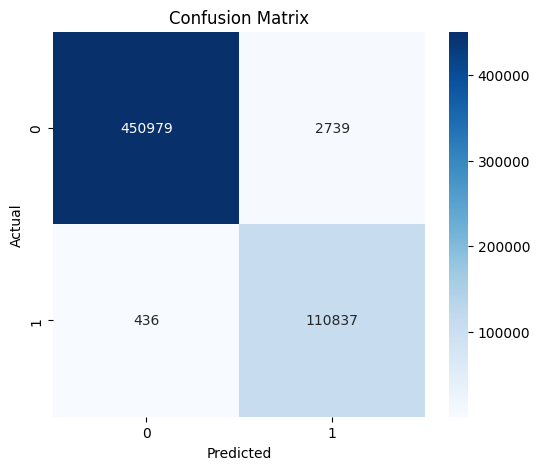

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the model’s ability to distinguish between benign and attack traffic across different classification thresholds.

---

### Key Metric

- **Area Under the Curve (AUC): 0.9996**

---

### Interpretation of ROC Curve

- The ROC curve plots:
  - **True Positive Rate (Recall)** on the Y-axis  
  - **False Positive Rate** on the X-axis  

- The curve is very close to the **top-left corner**, which indicates:
  - High true positive rate  
  - Very low false positive rate  

- The dashed diagonal line represents a **random classifier**, while the model’s curve significantly outperforms this baseline.

---

### Performance Insights

- An **AUC score of 0.9996** indicates **near-perfect classification performance**.
- The model is highly effective in distinguishing between benign and malicious traffic.
- Even at very low false positive rates, the model maintains a very high true positive rate.

---

### Practical Significance

- The high AUC value suggests that the model can reliably rank attack traffic higher than benign traffic.
- This is particularly important in intrusion detection systems where:
  - Missing attacks (false negatives) is critical  
  - Maintaining low false alarms is desirable  

---

### Conclusion

The ROC curve demonstrates that the model has **excellent discriminative ability**, achieving near-perfect separation between classes. While the performance is highly promising, further validation on more challenging or real-world datasets is recommended to ensure generalization.

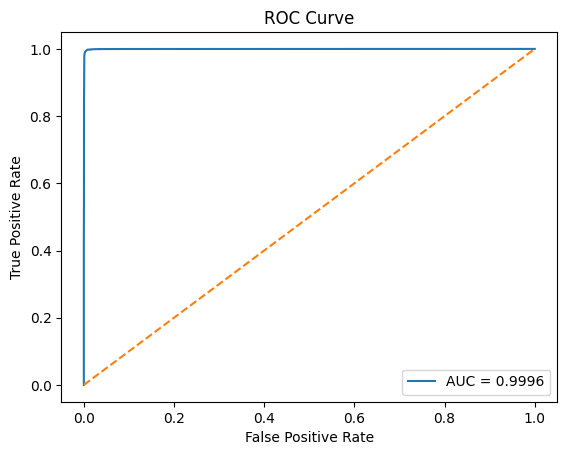

In [17]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf.predict_proba(X_test_top)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model to identify the most influential features contributing to intrusion detection.

---

### Overview

- The plot displays the **top 15 most important features** ranked based on their contribution to the model.
- Importance values indicate how much each feature reduces impurity across the trees in the forest.

---

### Key Observations

#### 1. Destination Port (Highest Importance)
- This is the most significant feature in the model.
- Indicates that certain ports are strongly associated with either benign or malicious traffic.

---

#### 2. Packet Length Features

Several packet length-related features contribute significantly:

- **Max Packet Length**
- **Average Packet Size**
- **Packet Length Variance**
- **Packet Length Std**
- **Packet Length Mean**

These features capture:
- Traffic volume characteristics  
- Packet distribution patterns  

👉 These are strong indicators of abnormal network behavior.

---

#### 3. Backward Packet Features

Important backward flow features include:

- **Bwd Packet Length Min**
- **Bwd Packet Length Mean**
- **Bwd Packet Length Std**
- **Bwd Packet Length Max**
- **Avg Bwd Segment Size**

These features reflect:
- Response behavior from the destination  
- Differences between normal and attack communication patterns  

---

#### 4. Flow Control and Window Size Features

- **Init_Win_bytes_backward**
- **Init_Win_bytes_forward**

These features provide insight into:
- TCP flow control mechanisms  
- Potential anomalies in connection behavior  

---

#### 5. Forward Packet Features

- **Fwd Packet Length Min**
- **Fwd Packet Length Max**

These help capture:
- Outgoing traffic characteristics  
- Deviations from typical packet structures  

---

### Interpretation

- The model relies heavily on **network traffic behavior features**, particularly packet size and flow characteristics.
- The dominance of packet-related features suggests that **statistical properties of network flows are highly effective in distinguishing attacks from benign traffic**.
- The importance distribution is relatively spread out, indicating that multiple features contribute meaningfully rather than relying on a single dominant feature.

---

### Conclusion

The feature importance analysis highlights that **packet-level and flow-based characteristics are the most critical factors in intrusion detection**. By selecting the top features, the model achieves:

- Reduced dimensionality  
- Improved computational efficiency  
- Maintained high predictive performance  

This step also enhances the interpretability of the model by identifying the key drivers behind classification decisions.

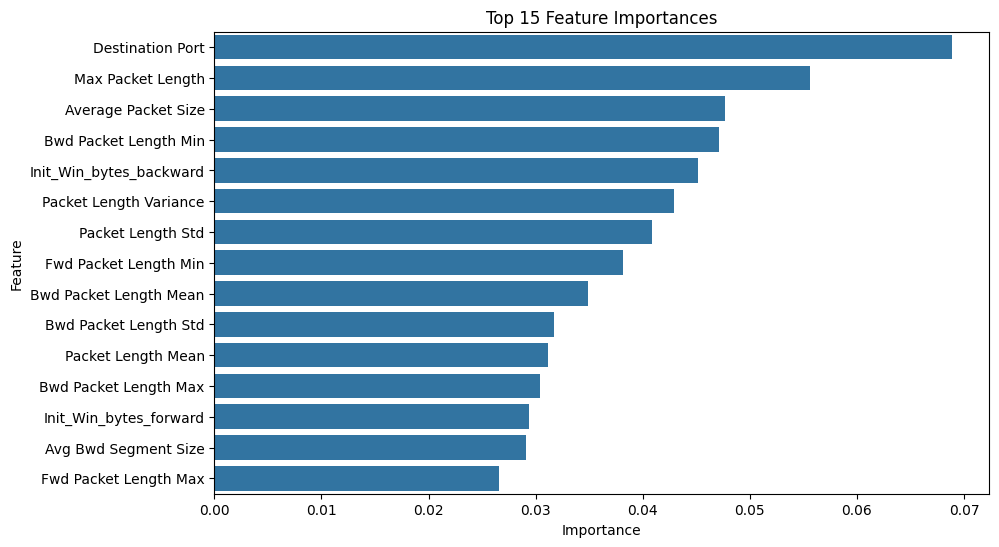

In [18]:
top_n = 15

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importance_df.head(top_n)["Importance"],
    y=feature_importance_df.head(top_n)["Feature"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Learning Curve Analysis

The learning curve illustrates the model’s performance as a function of the training data size, providing insights into **generalization ability, overfitting, and model stability**.

---

### Overview

- The plot shows:
  - **Training Score (Blue Line)**  
  - **Validation Score (Orange Line)**  
- The evaluation metric used is **F1-score**.

---

### Key Observations

#### 1. High Training Performance

- The training score starts high (~0.989) and gradually increases to ~0.996.
- This indicates that the model is able to learn patterns effectively from the training data.

---

#### 2. Improving Validation Performance

- The validation score improves significantly as the training size increases:
  - From ~0.972 to ~0.992  
- This shows that the model benefits from additional data and becomes more accurate on unseen data.

---

#### 3. Small Gap Between Training and Validation

- The gap between training and validation scores is very small (~0.003–0.004).
- This suggests:
  - Minimal overfitting  
  - Good generalization capability  

---

#### 4. Convergence of Curves

- As the training size increases:
  - Training and validation curves move closer together  
- This indicates that the model is achieving a good balance between bias and variance.

---

### Interpretation

- The model demonstrates **strong learning capability** and maintains consistent performance across different training sizes.
- The steady improvement in validation performance indicates that the model is not memorizing the data but learning generalizable patterns.
- The absence of a large gap between the curves confirms that the model is **not significantly overfitting**.

---

### Conclusion

The learning curve suggests that the model is **well-generalized and stable**, with a good balance between bias and variance. While performance is already high, the slight upward trend indicates that additional data could still provide marginal improvements.

However, given the high performance, further evaluation using more challenging data splits (e.g., time-based or unseen attack types) is recommended to validate real-world applicability.

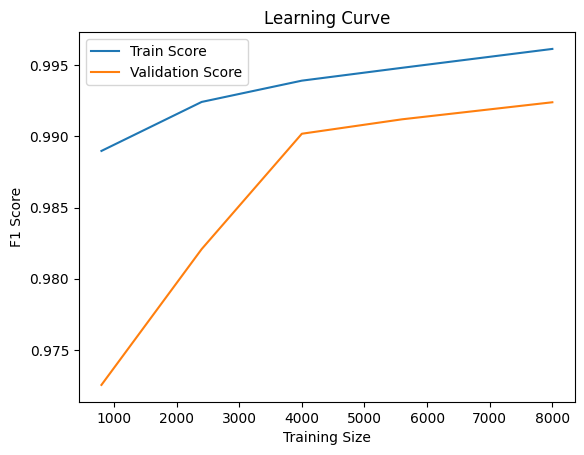

In [19]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_top, y_train_bal,
    cv=5, scoring='f1',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0]
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()

## Unsupervised Learning & Dimensionality Reduction 

In [20]:
# Import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Data Preparation for Unsupervised Learning

To prepare the dataset for unsupervised learning algorithms such as clustering and dimensionality reduction:

1. **Feature Selection**: Use the selected features from the correlation-based feature selection step (`df_selected`), which contains 52 features after removing highly correlated ones.

2. **Target Variable Removal**: Drop the "Label" column to ensure the algorithms operate without knowledge of the target variable, preventing bias and allowing for true unsupervised pattern discovery.

3. **Feature Scaling**: Apply standardization using `StandardScaler` to transform features to have a mean of 0 and standard deviation of 1. This is crucial for:
   - Distance-based algorithms like K-Means, where features with larger scales would dominate distance calculations
   - PCA, which is sensitive to feature scales
   - Ensuring all features contribute equally to the analysis

This preprocessing ensures the data is suitable for algorithms like K-Means clustering and PCA dimensionality reduction.

In [21]:
# Prepare unsupervised data by dropping the target variable
X_unsupervised = df_selected.drop(columns=["Label"]).copy()
print(f"Training data shape (features only): {X_unsupervised.shape}")

# Standardize features for unsupervised learning algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)
print(f"\nData scaled. Shape: {X_scaled.shape}")

Training data shape (features only): (2824951, 52)

Data scaled. Shape: (2824951, 52)


### PCA Explained Variance Analysis

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional space by creating new features called principal components. The explained variance plots are essential for understanding the effectiveness of this transformation.

#### Why PCA Explained Variance Plots are Required

1. **Component Importance**: Identify which components capture the most information (variance) from the original data.
2. **Dimensionality Reduction Decision**: Determine how many components to keep to retain a sufficient amount of variance (e.g., 95%) without losing critical information.
3. **Data Structure Insight**: The rate at which variance is explained can reveal the underlying structure of the data, such as whether it's low-rank or has many independent features.
4. **Efficiency**: Reducing dimensions improves computational efficiency for subsequent algorithms like clustering (K-Means) while minimizing information loss.

In this context, for unsupervised learning on network intrusion detection data, PCA reduces the feature space from 52 dimensions to 25 components that explain 95% of the variance, making clustering more efficient and potentially revealing patterns in benign vs. attack traffic.



In [22]:
# PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced shape:", X_pca.shape)


# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components needed for 95% variance: {n_components_95}")


print("PCA visualization generated")
print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

PCA reduced shape: (2824951, 25)

Number of components needed for 95% variance: 25
PCA visualization generated
Original dimensions: 52
Reduced dimensions: 25
Explained variance ratio: [0.19360876 0.09909755 0.06833006 0.06649781 0.05288822 0.04569667
 0.04474479 0.03564154 0.03136508 0.02802422 0.02670226 0.02540194
 0.02433349 0.02331422 0.02274582 0.02232878 0.02102243 0.01970102
 0.01866691 0.01745783 0.01711487 0.01544934 0.01336169 0.01215208
 0.00994796]



#### Plot 1: Individual Explained Variance

This bar plot shows the explained variance ratio for each principal component. Each bar represents how much variance in the data is explained by that specific component. The height of the bar indicates the importance of that component in capturing the data's variability. Typically, the first few components explain the most variance, and the bars decrease in height as we move to higher components.

Text(0.5, 1.0, 'Individual Explained Variance')

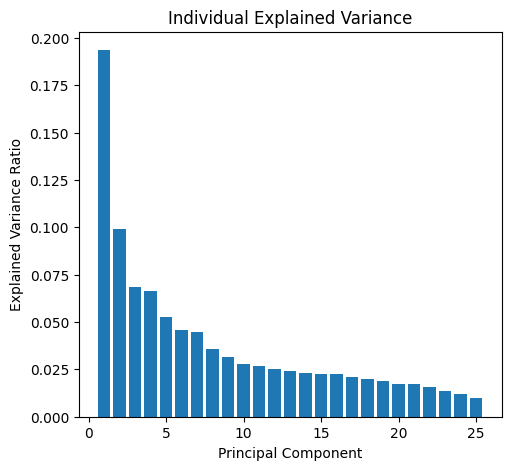

In [23]:
# Plot 1: Individual explained variance

# Plot explained variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance')


#### Plot 2: Cumulative Explained Variance

This line plot displays the cumulative explained variance as more principal components are added. The blue line shows how much total variance is explained by the first n components. The red dashed line marks the 95% threshold, and the green dashed line indicates the number of components needed to reach at least 95% of the total variance. This helps determine the optimal number of components to retain for dimensionality reduction while preserving most of the information.

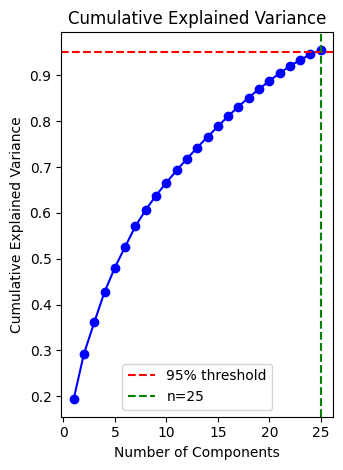

In [24]:
# Plot 2: Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'n={n_components_95}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

### Apply K-Means Clustering

Full dataset size: (2824951, 25)
Sample size for optimization: 50000 records
k=2: Inertia=1694726.06, Silhouette=0.4873
k=3: Inertia=1626841.27, Silhouette=0.3017
k=4: Inertia=1412410.25, Silhouette=0.2009
k=5: Inertia=1396591.96, Silhouette=0.1294
k=6: Inertia=1293095.89, Silhouette=0.2626
k=7: Inertia=1243987.85, Silhouette=0.2451
k=8: Inertia=1139652.09, Silhouette=0.1984
k=9: Inertia=1073058.38, Silhouette=0.1708
k=10: Inertia=1001785.65, Silhouette=0.3452


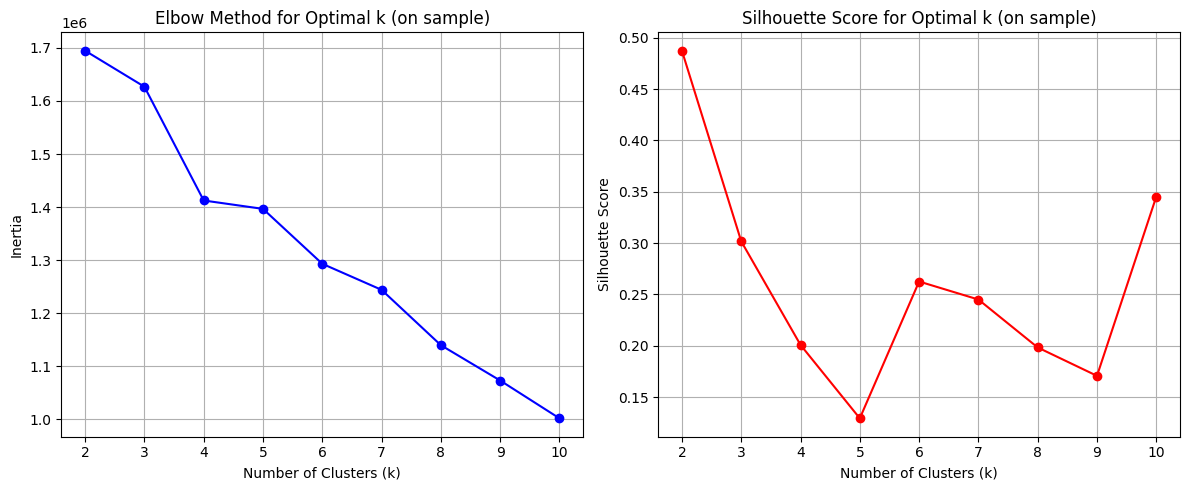


--- Automated Selection: Optimal k = 2 ---

Applying K-Means with k=2 to full dataset...
Clustering completed with 2 clusters
Cluster sizes: [2566044  258907]


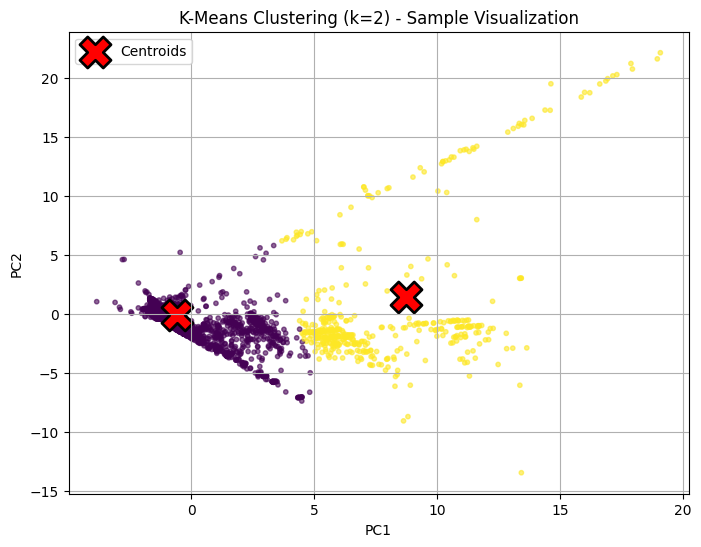


Note: Visualization shows 5,000 sampled points out of 2,824,951 total points

Unsupervised learning results recorded

Visualization shows the separation of network traffic into 2  clusters using K-Means algorithm

Red X marks indicate cluster centroids in the reduced dimensional space


In [ ]:
# Apply K-Means Clustering on PCA-reduced data (optimized for large datasets)
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print(f"Full dataset size: {X_pca.shape}")

# 1. Setup Parameters
# For large datasets, use a subset to determine optimal k (Elbow + Silhouette)
sample_size = min(50000, len(X_pca))  # Use 50k samples 
batch_size = 5000
K_range = range(2, 11)

# 2. Sampling for Optimization
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), sample_size, replace=False)
X_sample = X_pca[sample_idx]

print(f"Sample size for optimization: {sample_size} records")

# Determine optimal number of clusters using Elbow Method and Silhouette Score
inertias = []
silhouette_scores = []

# 3. Optimization Loop
for k in K_range:
    # n_init=3 helps avoid poor local optima in mini-batches
    kmeans_sample = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, random_state=42, n_init=10)
    kmeans_sample.fit(X_sample)

    inertias.append(kmeans_sample.inertia_)
    sil_score = silhouette_score(X_sample, kmeans_sample.labels_)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans_sample.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Plot Elbow Method and Silhouette Scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (on sample)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k (on sample)')
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Automated k Selection
# We choose k that maximizes the Silhouette Score
# Apply optimal k to full dataset using MiniBatchKMeans
optimal_k = 2
#optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n--- Manual Selection: Optimal k = {optimal_k} ---")
print(f"\nApplying K-Means with k={optimal_k} to full dataset...")


# 5. Final Fit on Full Dataset
# Using a larger batch size here (2k) speeds up the final pass
kmeans = MiniBatchKMeans(n_clusters=optimal_k, batch_size=batch_size*2, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

print(f"Clustering completed with {optimal_k} clusters")
print(f"Cluster sizes: {np.bincount(cluster_labels)}")

# Visualize clusters using a sample (using first 2 PCA components)
viz_idx = np.random.choice(len(X_pca), min(batch_size, len(X_pca)), replace=False)
X_viz = X_pca[viz_idx]
labels_viz = cluster_labels[viz_idx]

plt.figure(figsize=(8, 6))
plt.scatter(X_viz[:, 0], X_viz[:, 1], c=labels_viz, cmap='viridis', alpha=0.6, s=10)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           s=500, c='red', marker='X', label='Centroids', edgecolors='black', linewidth=2)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (k={optimal_k}) - Sample Visualization')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nNote: Visualization shows {len(X_viz):,} sampled points out of {len(X_pca):,} total points")

print(f"\nUnsupervised learning results recorded")
print(f"\nVisualization shows the separation of network traffic into {optimal_k}  clusters using K-Means algorithm")
print(f"\nRed X marks indicate cluster centroids in the reduced dimensional space")

In [40]:
df_clusters = pd.DataFrame({
    "cluster": cluster_labels,
    "true_label": df["Traffic_Label"]
})
cluster_mapping = df_clusters.groupby("cluster")["true_label"].mean()
print(cluster_mapping)

NameError: name 'cluster_labels' is not defined

Prepare data for unsupervised

In [ ]:
# TRAIN (same as RF)
X_train_unsup = train_balanced.drop(columns=["Traffic_Label"])
y_train_unsup = train_balanced["Traffic_Label"]

# TEST (same as RF)
X_test_unsup = X_test.copy()
y_test_unsup = y_test.copy()

(20000, 77) (20000,)


Sacling fit only on train data

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_unsup)
X_test_scaled = scaler.transform(X_test_unsup)

PCA

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 77
Reduced features: 24


K means (fixed K = 2)

In [57]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(
    n_clusters=2,
    random_state=42,
    batch_size=5000,
    n_init=10
)

cluster_train = kmeans.fit_predict(X_train_pca)
cluster_test = kmeans.predict(X_test_pca)

Map cluster

In [58]:
df_clusters = pd.DataFrame({
    "cluster": cluster_train,
    "true_label": y_train_unsup.values
})

cluster_mapping = df_clusters.groupby("cluster")["true_label"].mean()

print("\nCluster Mapping (Mean Label):")
print(cluster_mapping)


Cluster Mapping (Mean Label):
cluster
0    0.398014
1    0.873253
Name: true_label, dtype: float64


Create mapping

In [59]:
cluster_to_label = {
    cluster: int(val > 0.5)
    for cluster, val in cluster_mapping.items()
}

print("\nCluster → Label Mapping:", cluster_to_label)


Cluster → Label Mapping: {0: 0, 1: 1}


Predict on test data set + map + add distance from cluster

In [47]:
cluster_pred_test = pd.Series(cluster_test).map(cluster_to_label)
test_dist = kmeans.transform(X_test_pca)
model_3_data_frame["cluster_dist_0"] = test_dist[:, 0]
model_3_data_frame["cluster_dist_1"] = test_dist[:, 1]
model_3_data_frame["cluster_pred"] = cluster_pred_test.values

model_3_data_frame.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,rf_pred,rf_prob,cluster_pred,cluster_dist_0,cluster_dist_1
2731287,53,161,2,2,62,94,31,31,31.00000,0.000000,...,0,0.0,0.0,0,0,0,0.000000,0,2.057843,10.097578
2803437,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0,0.0,0.0,0,0,0,0.042055,0,4.771739,10.672182
1920623,80,5259727,4,4,437,839,437,0,109.25000,218.500000,...,0,0.0,0.0,0,0,0,0.000000,0,2.830429,9.580702
644010,443,3,2,0,12,0,6,6,6.00000,0.000000,...,0,0.0,0.0,0,0,0,0.042055,0,4.771739,10.672182
1818676,443,191849,32,49,871,64661,389,0,27.21875,83.719476,...,0,0.0,0.0,0,0,0,0.000000,0,8.774047,10.961066


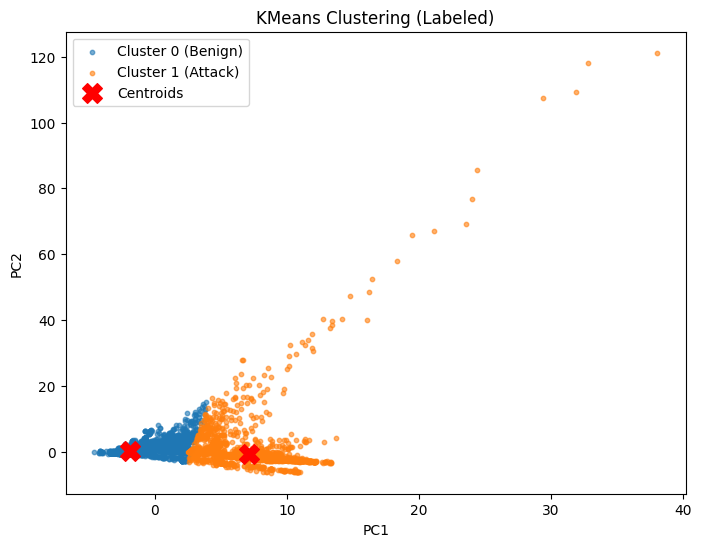

In [60]:
cluster_names = {
    cluster: "Attack" if label == 1 else "Benign"
    for cluster, label in cluster_to_label.items()
}
plt.figure(figsize=(8,6))

for cluster in np.unique(cluster_train):
    idx = cluster_train == cluster
    
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        s=10,
        alpha=0.6,
        label=f"Cluster {cluster} ({cluster_names[cluster]})"
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("KMeans Clustering (Labeled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

Classification report

In [64]:
from sklearn.metrics import classification_report

print("\nKMeans Classification Report:")
print(classification_report(y_test_unsup, cluster_pred_test))


KMeans Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90    453718
           1       0.63      0.35      0.45    111273

    accuracy                           0.83    564991
   macro avg       0.74      0.65      0.67    564991
weighted avg       0.81      0.83      0.81    564991



Confusion matrix

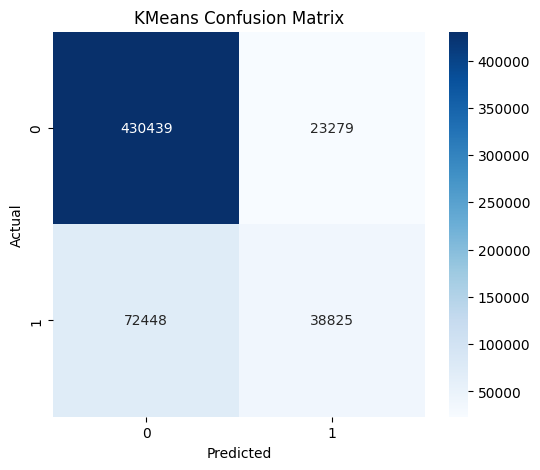

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_unsup, cluster_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KMeans Confusion Matrix")

plt.show()

Silhoutee score

In [51]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_train_pca, cluster_train)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.4758


ROC curve

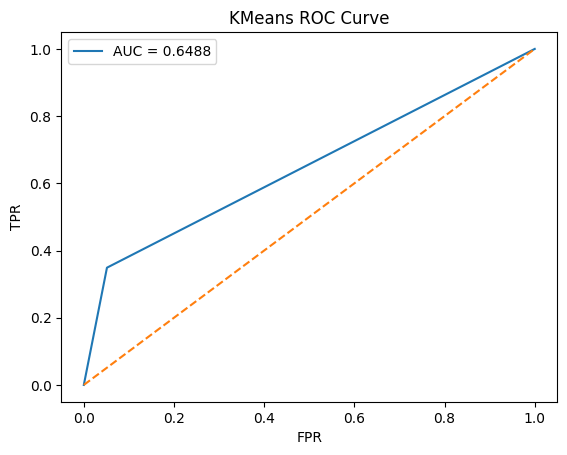

In [52]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_unsup, cluster_pred_test)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], '--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("KMeans ROC Curve")
plt.legend()
plt.show()